# Install & Import

In [ ]:
!pip install  scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 9.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load the Dataset

In [ ]:
import pandas as pd

file_path =  "/content/drive/MyDrive/NLP_Project/combined_dataset.csv"
df = pd.read_csv(file_path)

# Contoh: anggap df sudah ada
# df['clean_text'], df['encoded_label']

X = df['clean_text'].astype(str)
y = df['encoded_label']

# ==========================
# Train–Val–Test Split
# ==========================

# Step 1: Test set 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: From remaining 80%, take 12.5% as validation
# 12.5% dari 80% = 10% dari total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 1445
Validation size: 207
Test size: 414


# TF-IDF Vectorization

In [ ]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)


# Train Final Model (dengan hyperparameter terbaik)

In [ ]:
# Best Hyperparameters: {'C': 2.943518545256506, 'kernel': 'rbf', 'gamma': 0.7087455975220841}

best_C = 2.943518545256506
best_kernel = 'rbf'
best_gamma = 0.7087455975220841

final_model = SVC(
    C=best_C,
    kernel=best_kernel,
    gamma=best_gamma,
    probability=True,
    random_state=42
)

# Combine Train + Validation
X_final = vectorizer.fit_transform(pd.concat([X_train, X_val]))
y_final = pd.concat([y_train, y_val]).values

final_model.fit(X_final, y_final)


# === Evaluation on TEST set ===
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Corrected: Transform X_test using the fitted vectorizer
y_pred = final_model.predict(vectorizer.transform(X_test))


f1_macro = f1_score(y_test, y_pred, average="macro")
cls_report = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

print("\n=== Final BiGRU Test Evaluation ===")
print("F1-macro:", f1_macro)
print("Accuracy:", cls_report["accuracy"])
print("Classification Report:", cls_report)
print("Confusion Matrix:\n", cm)

# === Inference Time Benchmark (selaras dengan BERT) ===
import time
# Corrected: Transform X_test for benchmarking
X_test_transformed = vectorizer.transform(X_test)
benchmark_size = min(32, X_test_transformed.shape[0]) # Fix: Changed len() to .shape[0]
subset = X_test_transformed[:benchmark_size]

# Warm-up
for _ in range(3):
    _ = final_model.predict(subset)

# Benchmark
n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = final_model.predict(subset)
end = time.time()

avg_time = (end - start) / n_runs
samples_per_second = benchmark_size / avg_time

print("\n🕒 Avg batch inference time:", avg_time)
print("📊 Throughput:", samples_per_second, "samples/sec")


=== Final BiGRU Test Evaluation ===
F1-macro: 0.8784592617445643
Accuracy: 0.8816425120772947
Classification Report: {'0.0': {'precision': 0.8537549407114624, 'recall': 0.9473684210526315, 'f1-score': 0.8981288981288982, 'support': 228.0}, '1.0': {'precision': 0.9254658385093167, 'recall': 0.8010752688172043, 'f1-score': 0.8587896253602305, 'support': 186.0}, 'accuracy': 0.8816425120772947, 'macro avg': {'precision': 0.8896103896103895, 'recall': 0.874221844934918, 'f1-score': 0.8784592617445643, 'support': 414.0}, 'weighted avg': {'precision': 0.8859728803018028, 'recall': 0.8816425120772947, 'f1-score': 0.8804547321023953, 'support': 414.0}}
Confusion Matrix:
 [[216  12]
 [ 37 149]]

🕒 Avg batch inference time: 0.004046373367309571
📊 Throughput: 7908.3161871631155 samples/sec


Mapping encoded_label -> class name:
0.0 -> Bullying
1.0 -> Non-bullying

Class names (urutan sesuai encoded label):
['Bullying', 'Non-bullying']

 Final Model F1 Score (Test, macro): 0.8785

 Classification Report:

              precision    recall  f1-score   support

    Bullying     0.8538    0.9474    0.8981       228
Non-bullying     0.9255    0.8011    0.8588       186

    accuracy                         0.8816       414
   macro avg     0.8896    0.8742    0.8785       414
weighted avg     0.8860    0.8816    0.8805       414



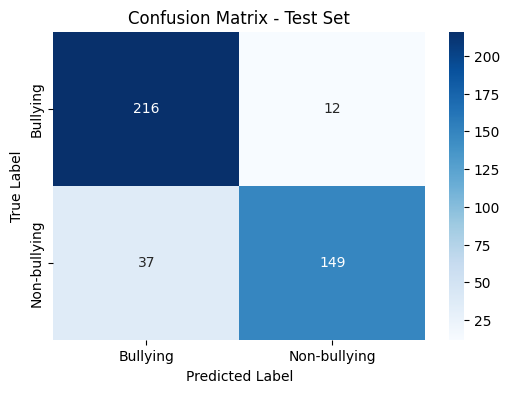

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Prediksi ---
# X_test_tfidf was generated with the vectorizer fitted on X_train only.
# The 'vectorizer' object itself was re-fitted on X_train + X_val in the previous cell.
# We need to transform X_test using the current state of the vectorizer.
y_pred = final_model.predict(vectorizer.transform(X_test))

# --- Mapping label biner ---
label_mapping = {
    0.0: "Bullying",
    1.0: "Non-bullying"
}

# Urutkan sesuai nilai encoded label
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

print("Mapping encoded_label -> class name:")
for k, v in label_mapping.items():
    print(f"{k} -> {v}")

print("\nClass names (urutan sesuai encoded label):")
print(class_names)

# --- Evaluasi ---
f1 = f1_score(y_test, y_pred, average="macro")
print(f"\n Final Model F1 Score (Test, macro): {f1:.4f}")

# Classification Report
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.show()